<a href="https://colab.research.google.com/github/dhafi7/finalterm_MachineLearning/blob/main/Transaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q pandas numpy matplotlib scikit-learn tensorflow optuna mlflow

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 4.8 MB/s eta 0:00

In [2]:
import os
import gc
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import optuna
import mlflow
import mlflow.tensorflow

In [5]:
DATA_PATH = "/content/drive/MyDrive/Datasets ML/train_transaction.csv"

os.makedirs("reports", exist_ok=True)
os.makedirs("models", exist_ok=True)

In [6]:
df = pd.read_csv(DATA_PATH)

print("Dataset berhasil dibaca.")
print("Shape dataset:", df.shape)

df.head()

print(df.columns.tolist())

if "isFraud" in df.columns:
    print("Kolom target isFraud ditemukan.")
else:
    print("Kolom target isFraud tidak ditemukan.")

Dataset berhasil dibaca.
Shape dataset: (590540, 394)
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


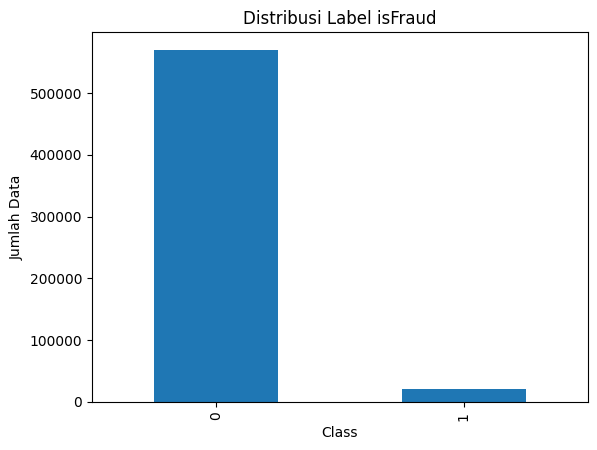

,0
dist2,93.628374
D7,93.409930
D13,89.509263
D14,89.469469
D12,89.041047
D6,87.606767
D8,87.312290
D9,87.312290
V162,86.123717
V142,86.123717


In [7]:
df.info()
df.describe()
df["isFraud"].value_counts()
df["isFraud"].value_counts(normalize=True) * 100
df["isFraud"].value_counts().plot(kind="bar")
plt.title("Distribusi Label isFraud")
plt.xlabel("Class")
plt.ylabel("Jumlah Data")
plt.show()
missing_values = df.isnull().mean().sort_values(ascending=False) * 100
missing_values.head(20)

In [8]:
threshold = 90

missing_percentage = df.isnull().mean() * 100
columns_to_drop = missing_percentage[missing_percentage > threshold].index

print("Jumlah kolom yang dihapus:", len(columns_to_drop))

df = df.drop(columns=columns_to_drop)

print("Shape setelah drop missing columns:", df.shape)

Jumlah kolom yang dihapus: 2
Shape setelah drop missing columns: (590540, 392)


In [9]:
target = "isFraud"

X = df.drop(columns=[target])
y = df[target]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

if "TransactionID" in X.columns:
    X = X.drop(columns=["TransactionID"])
    print("TransactionID dihapus karena hanya identifier.")

Shape X: (590540, 391)
Shape y: (590540,)
TransactionID dihapus karena hanya identifier.


In [10]:
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Jumlah kolom numerik:", len(numeric_cols))
print("Jumlah kolom kategorikal:", len(categorical_cols))

Jumlah kolom numerik: 376
Jumlah kolom kategorikal: 14


In [11]:
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna("Unknown")

print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


In [12]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("Encoding selesai.")

Encoding selesai.


In [13]:
scaler = StandardScaler()

X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Scaling selesai.")

Scaling selesai.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (472432, 390)
X_test: (118108, 390)
y_train: (472432,)
y_test: (118108,)


In [15]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weight:", class_weight_dict)

Class weight: {np.int64(0): np.float64(0.5181288961224123), np.int64(1): np.float64(14.290139140955837)}


In [16]:
input_dim = X_train.shape[1]

model_baseline = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_baseline.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        50,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_baseline = model_baseline.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=512,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8088 - auc: 0.8497 - loss: 0.4766 - val_accuracy: 0.7497 - val_auc: 0.8692 - val_loss: 0.5262
Epoch 2/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8308 - auc: 0.8794 - loss: 0.4302 - val_accuracy: 0.8544 - val_auc: 0.8843 - val_loss: 0.3600
Epoch 3/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8413 - auc: 0.8940 - loss: 0.4061 - val_accuracy: 0.8164 - val_auc: 0.8914 - val_loss: 0.4294
Epoch 4/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8492 - auc: 0.9032 - loss: 0.3889 - val_accuracy: 0.8337 - val_auc: 0.8963 - val_loss: 0.3884
Epoch 5/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8561 - auc: 0.9114 - loss: 0.3738 - val_accuracy: 0.8307 - val_auc: 0.8959 - val_loss: 0.4017


In [18]:
y_pred_proba = model_baseline.predict(X_test).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

3691/3691 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
Accuracy: 0.8540149693500864
Precision: 0.16051173149634848
Recall: 0.749818533752722
F1 Score: 0.264419795221843
ROC-AUC: 0.8852934944887705
PR-AUC: 0.5043555168348876

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    113975
           1       0.16      0.75      0.26      4133

    accuracy                           0.85    118108
   macro avg       0.58      0.80      0.59    118108
weighted avg       0.96      0.85      0.90    118108

[[97767 16208]
 [ 1034  3099]]


In [19]:
model_dropout = Sequential([
    Dense(256, activation="relu", input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model_dropout.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       100,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,849 (558.00 KB)

 Trainable params: 142,081 (555.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [20]:
history_dropout = model_dropout.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=512,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7697 - auc: 0.8222 - loss: 0.5176 - val_accuracy: 0.7886 - val_auc: 0.8611 - val_loss: 0.4461
Epoch 2/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8021 - auc: 0.8568 - loss: 0.4674 - val_accuracy: 0.8698 - val_auc: 0.8710 - val_loss: 0.3686
Epoch 3/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8126 - auc: 0.8687 - loss: 0.4487 - val_accuracy: 0.8367 - val_auc: 0.8802 - val_loss: 0.4061


In [21]:
y_pred_proba_dropout = model_dropout.predict(X_test).ravel()
y_pred_dropout = (y_pred_proba_dropout >= 0.5).astype(int)

results_dropout = {
    "Accuracy": accuracy_score(y_test, y_pred_dropout),
    "Precision": precision_score(y_test, y_pred_dropout),
    "Recall": recall_score(y_test, y_pred_dropout),
    "F1 Score": f1_score(y_test, y_pred_dropout),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_dropout),
    "PR-AUC": average_precision_score(y_test, y_pred_proba_dropout)
}

results_dropout

3691/3691 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step


{'Accuracy': 0.7900480915772006,
 'Precision': 0.11724827739497666,
 'Recall': 0.7657875635131866,
 'F1 Score': 0.2033604266392521,
 'ROC-AUC': np.float64(0.8608997276188577),
 'PR-AUC': np.float64(0.43471491458268263)}

In [22]:
def objective(trial):
    tf.keras.backend.clear_session()

    n_units_1 = trial.suggest_int("n_units_1", 64, 256)
    n_units_2 = trial.suggest_int("n_units_2", 32, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [256, 512, 1024])

    model = Sequential([
        Dense(n_units_1, activation="relu", input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(n_units_2, activation="relu"),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(1, activation="sigmoid")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    early_stop = EarlyStopping(
        monitor="val_auc",
        patience=2,
        mode="max",
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=5,
        batch_size=batch_size,
        callbacks=[early_stop],
        class_weight=class_weight_dict,
        verbose=0
    )

    val_auc = max(history.history["val_auc"])

    return val_auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print("Best Trial:")
print(study.best_trial.params)
print("Best AUC:", study.best_value)

[I 2026-06-19 13:34:26,859] A new study created in memory with name: no-name-019dc228-fba9-4e47-bfda-deefd121d84a
[I 2026-06-19 13:34:55,770] Trial 0 finished with value: 0.8960506319999695 and parameters: {'n_units_1': 231, 'n_units_2': 110, 'dropout_rate': 0.11499555798467309, 'learning_rate': 0.0012950604278565976, 'batch_size': 512}. Best is trial 0 with value: 0.8960506319999695.
[I 2026-06-19 13:35:36,664] Trial 1 finished with value: 0.8878920674324036 and parameters: {'n_units_1': 92, 'n_units_2': 118, 'dropout_rate': 0.11635583672785708, 'learning_rate': 0.008563298606195188, 'batch_size': 512}. Best is trial 0 with value: 0.8960506319999695.
[I 2026-06-19 13:36:04,441] Trial 2 finished with value: 0.8816508054733276 and parameters: {'n_units_1': 71, 'n_units_2': 64, 'dropout_rate': 0.34174639691555264, 'learning_rate': 0.0009570654590589931, 'batch_size': 512}. Best is trial 0 with value: 0.8960506319999695.
[I 2026-06-19 13:36:32,330] Trial 3 finished with value: 0.878201961

Best Trial:
{'n_units_1': 231, 'n_units_2': 110, 'dropout_rate': 0.11499555798467309, 'learning_rate': 0.0012950604278565976, 'batch_size': 512}
Best AUC: 0.8960506319999695


In [23]:
best_params = study.best_trial.params

tf.keras.backend.clear_session()

best_model = Sequential([
    Dense(best_params["n_units_1"], activation="relu", input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(best_params["dropout_rate"]),

    Dense(best_params["n_units_2"], activation="relu"),
    BatchNormalization(),
    Dropout(best_params["dropout_rate"]),

    Dense(1, activation="sigmoid")
])

optimizer = tf.keras.optimizers.Adam(learning_rate=best_params["learning_rate"])

best_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history_best = best_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=best_params["batch_size"],
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7928 - auc: 0.8402 - loss: 0.4945 - val_accuracy: 0.8256 - val_auc: 0.8657 - val_loss: 0.4186
Epoch 2/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8193 - auc: 0.8716 - loss: 0.4438 - val_accuracy: 0.8801 - val_auc: 0.8803 - val_loss: 0.3364
Epoch 3/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8321 - auc: 0.8838 - loss: 0.4236 - val_accuracy: 0.8923 - val_auc: 0.8822 - val_loss: 0.3115
Epoch 4/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8383 - auc: 0.8920 - loss: 0.4090 - val_accuracy: 0.8599 - val_auc: 0.8904 - val_loss: 0.3516
Epoch 5/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8458 - auc: 0.8995 - loss: 0.3957 - val_accuracy: 0.8677 - val_auc: 0.8964 - val_loss: 0.3453
Epoch 6/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8510 - auc: 0.9055 - loss: 0.3846 - val_accuracy: 0.8660 - val_auc: 0.8996 - val_loss: 0.3400


In [24]:
y_pred_proba_best = best_model.predict(X_test).ravel()
y_pred_best = (y_pred_proba_best >= 0.5).astype(int)

results_best = {
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall": recall_score(y_test, y_pred_best),
    "F1 Score": f1_score(y_test, y_pred_best),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_best),
    "PR-AUC": average_precision_score(y_test, y_pred_proba_best)
}

results_best

3691/3691 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


{'Accuracy': 0.8914637450469062,
 'Precision': 0.19857023875624652,
 'Recall': 0.6922332446165014,
 'F1 Score': 0.3086133434011111,
 'ROC-AUC': np.float64(0.8831503251691522),
 'PR-AUC': np.float64(0.49185120590984643)}

In [25]:
results_baseline = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

comparison = pd.DataFrame([
    results_baseline,
    results_dropout,
    results_best
], index=[
    "Baseline MLP",
    "MLP Dropout BatchNorm",
    "Optuna Tuned MLP"
])

comparison

comparison.to_csv("reports/model_comparison.csv")

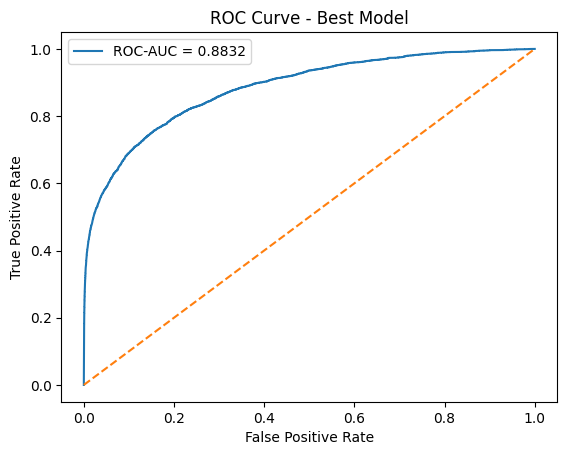

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {results_best['ROC-AUC']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()
plt.savefig("reports/roc_curve.png")
plt.show()

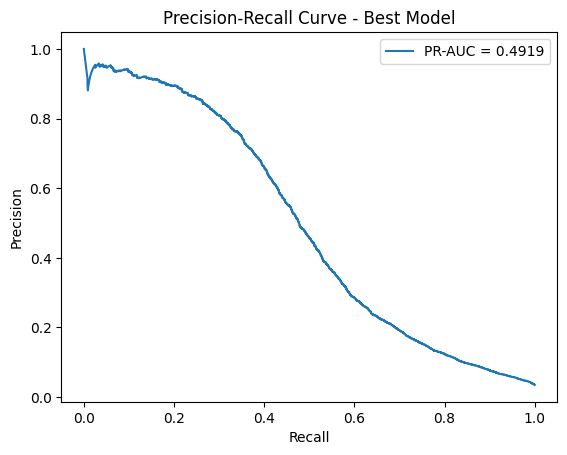

In [27]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba_best)

plt.figure()
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {results_best['PR-AUC']:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Best Model")
plt.legend()
plt.savefig("reports/precision_recall_curve.png")
plt.show()

In [29]:
import os
import mlflow
import mlflow.tensorflow

# Pakai SQLite sebagai backend MLflow agar tidak error di versi terbaru
mlflow.set_tracking_uri("sqlite:////content/mlflow.db")

experiment_name = "fraud_detection_finalterm"

# Buat experiment jika belum ada
if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(
        experiment_name,
        artifact_location="file:///content/mlflow_artifacts"
    )

mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name="Optuna_Tuned_MLP"):
    mlflow.log_params(best_params)

    mlflow.log_metric("accuracy", results_best["Accuracy"])
    mlflow.log_metric("precision", results_best["Precision"])
    mlflow.log_metric("recall", results_best["Recall"])
    mlflow.log_metric("f1_score", results_best["F1 Score"])
    mlflow.log_metric("roc_auc", results_best["ROC-AUC"])
    mlflow.log_metric("pr_auc", results_best["PR-AUC"])

    mlflow.tensorflow.log_model(best_model, "model")

    mlflow.log_artifact("reports/model_comparison.csv")
    mlflow.log_artifact("reports/roc_curve.png")
    mlflow.log_artifact("reports/precision_recall_curve.png")

print("MLflow logging selesai.")

2026/06/19 13:41:42 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 13:41:42 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 13:41:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 13:41:44 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


MLflow logging selesai.


In [30]:
best_model.save("models/best_fraud_detection_model.keras")

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [31]:
OUTPUT_DIR = "/content/drive/MyDrive/finalterm-machine-learning-result"

os.makedirs(OUTPUT_DIR, exist_ok=True)

!cp -r reports "{OUTPUT_DIR}"
!cp -r models "{OUTPUT_DIR}"
!cp -r /content/mlruns "{OUTPUT_DIR}"

print("Hasil berhasil disimpan ke Google Drive.")

cp: cannot stat '/content/mlruns': No such file or directory
Hasil berhasil disimpan ke Google Drive.
